Import the data CSV, group by empty cell count

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("../sudoku_boards_sorted.csv")


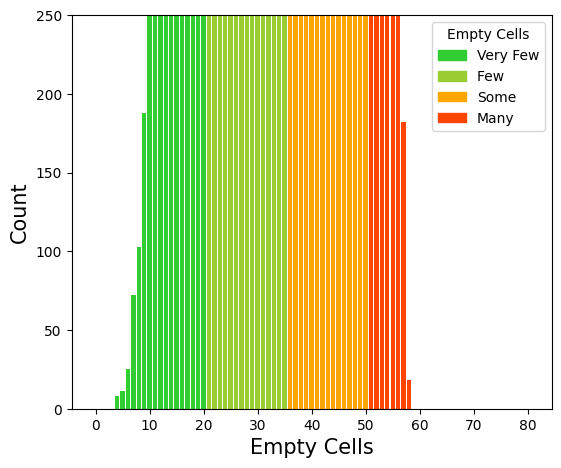

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

counts = df["zero_count"].value_counts().reindex(range(81), fill_value=0)

group_colors = {
    "Very Few": ("limegreen", range(4, 21)),
    "Few ": ("yellowgreen", range(21, 36)),
    "Some": ("orange", range(36, 51)),
    "Many": ("orangered", range(51, 60))
}

colors = []
x = np.arange(81)

for i in x:
    assigned = "white"
    for label, (c, r) in group_colors.items():
        if i in r:
            assigned = c
            break
    colors.append(assigned)

plt.bar(x, counts, color=colors)
plt.xlabel("Empty Cells", fontsize=15)
plt.ylabel("Count", fontsize=15)
plt.ylim(0, 250)

# ---- build the legend ----
patches = []
for label, (c, r) in group_colors.items():
    patches.append(mpatches.Patch(color=c, label=label))

plt.legend(handles=patches, title="Empty Cells")
plt.subplots_adjust(left=0.15)
plt.subplots_adjust(top=0.93)
plt.savefig("C:\\Users\\samgr\\PycharmProjects\\sudoku-cp-ai\\visualizations\\emptycells-cut.png")
plt.show()
